# Kuibit tutorial: reading ETK simulation output


### 1. Open a simulation with `SimDir`


In [21]:
import kuibit as kb
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

outdir = Path("./kuibit_tutorial_2026_workspace/")
bool_save = True
outdir.mkdir(parents=True, exist_ok=True)

def save_plot(filename, dpi=180):
    if not bool_save:
        return
    path = outdir / filename
    plt.gcf().savefig(path, dpi=dpi, bbox_inches="tight")
    print(path)

#Hardcoded BNS simulation output
bns_simout1 =  Path("/home/mrizzo/bnsCO_SLy_GRHayL_Baikal_nozref")


print(f"simulation output directory: {bns_simout1}")


simulation output directory: /home/mrizzo/bnsCO_SLy_GRHayL_Baikal_nozref


In [5]:
simdir1 = kb.simdir.SimDir(bns_simout1)
print(simdir1)

Indexed 620 files and 13 subdirectories
Folder /data/mrizzo7/ETK_Kruskal/simulations_kruskal/bnsCO_SLy_GRHayL_Baikal_nozref_orbit_r20_attempt2
/data/mrizzo7/ETK_Kruskal/simulations_kruskal/bnsCO_SLy_GRHayL_Baikal_nozref_orbit_r20_attempt2
Available scalar timeseries:
['qlm_origin_x[0]', 'qlm_origin_x[1]', 'qlm_origin_x[2]', 'qlm_origin_x[3]', 'qlm_origin_x[4]', 'qlm_origin_x[5]', 'qlm_origin_y[0]', 'qlm_origin_y[1]', 'qlm_origin_y[2]', 'qlm_origin_y[3]', 'qlm_origin_y[4]', 'qlm_origin_y[5]', 'qlm_origin_z[0]', 'qlm_origin_z[1]', 'qlm_origin_z[2]', 'qlm_origin_z[3]', 'qlm_origin_z[4]', 'qlm_origin_z[5]', 'qlm_origin_theta[0]', 'qlm_origin_theta[1]', 'qlm_origin_theta[2]', 'qlm_origin_theta[3]', 'qlm_origin_theta[4]', 'qlm_origin_theta[5]', 'qlm_origin_phi[0]', 'qlm_origin_phi[1]', 'qlm_origin_phi[2]', 'qlm_origin_phi[3]', 'qlm_origin_phi[4]', 'qlm_origin_phi[5]', 'qlm_delta_theta[0]', 'qlm_delta_theta[1]', 'qlm_delta_theta[2]', 'qlm_delta_theta[3]', 'qlm_delta_theta[4]', 'qlm_delta_thet

### 2. Time series and scalar reductions


In [6]:
print(simdir1.ts) # or simdir1.timeseries

Folder /data/mrizzo7/ETK_Kruskal/simulations_kruskal/bnsCO_SLy_GRHayL_Baikal_nozref_orbit_r20_attempt2
/data/mrizzo7/ETK_Kruskal/simulations_kruskal/bnsCO_SLy_GRHayL_Baikal_nozref_orbit_r20_attempt2
Available scalar timeseries:
['qlm_origin_x[0]', 'qlm_origin_x[1]', 'qlm_origin_x[2]', 'qlm_origin_x[3]', 'qlm_origin_x[4]', 'qlm_origin_x[5]', 'qlm_origin_y[0]', 'qlm_origin_y[1]', 'qlm_origin_y[2]', 'qlm_origin_y[3]', 'qlm_origin_y[4]', 'qlm_origin_y[5]', 'qlm_origin_z[0]', 'qlm_origin_z[1]', 'qlm_origin_z[2]', 'qlm_origin_z[3]', 'qlm_origin_z[4]', 'qlm_origin_z[5]', 'qlm_origin_theta[0]', 'qlm_origin_theta[1]', 'qlm_origin_theta[2]', 'qlm_origin_theta[3]', 'qlm_origin_theta[4]', 'qlm_origin_theta[5]', 'qlm_origin_phi[0]', 'qlm_origin_phi[1]', 'qlm_origin_phi[2]', 'qlm_origin_phi[3]', 'qlm_origin_phi[4]', 'qlm_origin_phi[5]', 'qlm_delta_theta[0]', 'qlm_delta_theta[1]', 'qlm_delta_theta[2]', 'qlm_delta_theta[3]', 'qlm_delta_theta[4]', 'qlm_delta_theta[5]', 'qlm_delta_phi[0]', 'qlm_delta_ph

In [7]:
print(simdir1.ts.max)

Available maximum timeseries:
['alp', 'betax', 'betay', 'betaz', 'HGF', 'MSQUAREDGF', 'MU0GF', 'MU1GF', 'MU2GF', 'rho', 'press', 'eps', 'vel[0]', 'vel[1]', 'vel[2]', 'grid_distance_1', 'grid_distance_2']



-------
[0.  2.4 4.8 7.2] [0.00142868 0.00142798 0.00142803 0.00142804]
kuibit_tutorial_2026_workspace/01_rhomax_timeseries.png


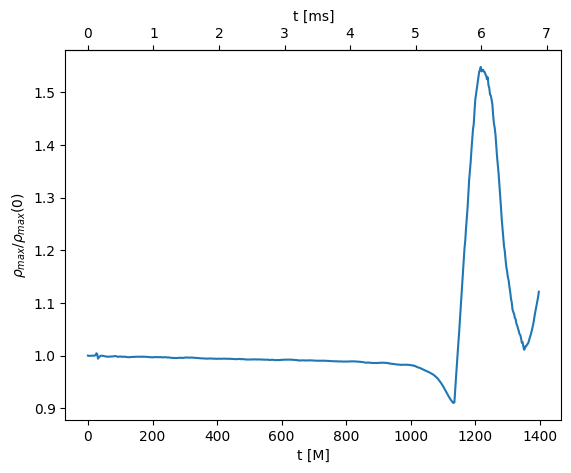

In [8]:
rho_max = simdir1.ts.max["rho"]
print(rho_max)
print("-------")
print(rho_max.t[:4], rho_max.values[:4])

# ETK code time is geometrized: G = c = Msun = 1.
UC = kb.unitconv.geom_umass_msun(1.0)

rho_max_normed = rho_max / rho_max.values[0]

plt.figure()
plt.plot(rho_max_normed)
plt.xlabel("t [M]")
plt.ylabel(r"$\rho_{max}/\rho_{max}(0)$")

# A second axis is often useful for talks and quick sanity checks.
ms_axis = plt.gca().secondary_xaxis(
    "top",
    functions=(
        lambda tcode: tcode * UC.time * 1e3,
        lambda t_ms: t_ms / (UC.time * 1e3),
    ),
)
ms_axis.set_xlabel("t [ms]")
save_plot("01_rhomax_timeseries.png")


In [9]:
# Construct your own timeseries
time_manual = np.linspace(0, 100, 1000)
sin_wave = kb.timeseries.TimeSeries(time_manual, np.sin(time_manual))
print(sin_wave)

# Interpolate with a function call.
print(f"should be near 0: {sin_wave(2*np.pi)}")

#dir(sin_wave)


should be near 0: 8.190038465125116e-09


Text(0.5, 0, 't [ms]')

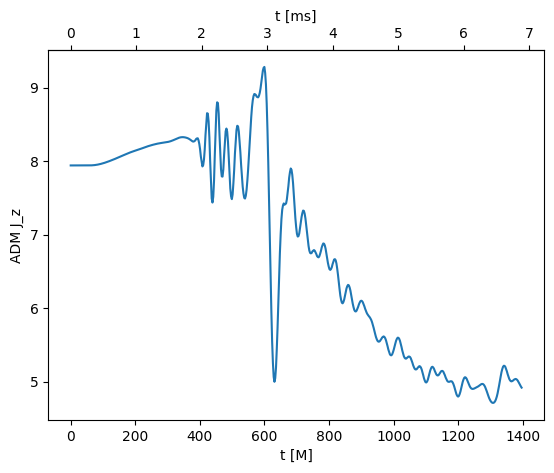

In [10]:
#True scalars accessible via .ts.scalar
plt.plot(simdir1.ts.scalar["qlm_adm_angular_momentum_z[5]"])

plt.xlabel("t [M]")
plt.ylabel(rf"ADM J_z")
ms_axis = plt.gca().secondary_xaxis(
    "top",
    functions=(
        lambda tcode: tcode * UC.time * 1e3,
        lambda t_ms: t_ms / (UC.time * 1e3),
    ),
)
ms_axis.set_xlabel("t [ms]")

### 3. Grid functions

Carpet I/O thorns can output GFs in 1D/2D/3D


In [11]:
print(simdir1.gf)
print("-------")
print(simdir1.gf.x)   # 1D x-axis output
print("-------")
print(simdir1.gf.xy)  # 2D xy output



Available grid data of dimension 1D (x): 
['gxx', 'gxy', 'gxz', 'gyy', 'gyz', 'gzz', 'kxx', 'kxy', 'kxz', 'kyy', 'kyz', 'kzz', 'alp', 'HGF', 'MSQUAREDGF', 'MU0GF', 'MU1GF', 'MU2GF', 'rho', 'press', 'vel[0]', 'vel[1]', 'vel[2]']


Available grid data of dimension 1D (y): 
['gxx', 'gxy', 'gxz', 'gyy', 'gyz', 'gzz', 'kxx', 'kxy', 'kxz', 'kyy', 'kyz', 'kzz', 'alp', 'HGF', 'MSQUAREDGF', 'MU0GF', 'MU1GF', 'MU2GF', 'rho', 'press', 'vel[0]', 'vel[1]', 'vel[2]']


Available grid data of dimension 1D (z): 
['gxx', 'gxy', 'gxz', 'gyy', 'gyz', 'gzz', 'kxx', 'kxy', 'kxz', 'kyy', 'kyz', 'kzz', 'alp', 'HGF', 'MSQUAREDGF', 'MU0GF', 'MU1GF', 'MU2GF', 'rho', 'press', 'vel[0]', 'vel[1]', 'vel[2]']


Available grid data of dimension 2D (xy): 
['gxx', 'gxy', 'gxz', 'gyy', 'gyz', 'gzz', 'alp', 'betax', 'betay', 'betaz', 'HGF', 'MU0GF', 'rho', 'press', 'vel[0]', 'vel[1]', 'vel[2]']


Available grid data of dimension 2D (xz): 
['gxx', 'gxy', 'gxz', 'gyy', 'gyz', 'gzz', 'alp', 'betax', 'betay', 'betaz', 'HGF'

In [12]:
rho_xh_its = simdir1.gf.x["rho"]
print(rho_xh_its.available_iterations[:5])

it = rho_xh_its.available_iterations[0]
rho_xh = rho_xh_its[it]
print(rho_xh)
rho_xh

/data/mrizzo7/ETK_SumSch/PlotScripts/.venv/lib/python3.14/site-packages/kuibit/cactus_grid_functions.py:1796: UserWarning: You are using ASCII files, which have no information about ghost zone information. Set the attribute num_ghost of this object to properly account for the ghost zones. 
  warnings.warn(


[0, 512, 1024, 1536, 2048]
Available refinement levels (components):
0 (1)
1 (1)
2 (1)
3 (1)
4 (1)
5 (1)
6 (1)
7 (1)
Spacing at coarsest level (0): [24.]
Spacing at finest level (7): [0.1875]


kuibit_tutorial_2026_workspace/02_rho_x_axis.png


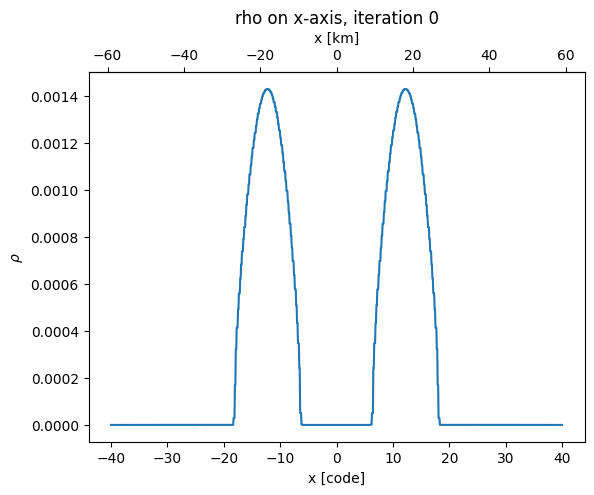

In [13]:
# Convert the HierarchicalGriData to UniformGridData
# resample=False asks kuibit to use the available data directly, without smoothing.
rho_x = rho_xh.to_UniformGridData((1024,), x0=(-40,), x1=(40,), resample=False) #!!! careful
x = rho_x.coordinates_meshgrid()[0]
km_per_code_length = UC.length / 1e3

fig, ax = plt.subplots()
ax.plot(x, rho_x.data)

ax.set_xlabel("x [code]")
ax.set_ylabel(r"$\rho$")
ax.set_title(f"rho on x-axis, iteration {it}")
km_axis = ax.secondary_xaxis(
    "top",
    functions=(
        lambda xcode: xcode * km_per_code_length,
        lambda x_km: x_km / km_per_code_length,
    ),
)
km_axis.set_xlabel("x [km]")
save_plot("02_rho_x_axis.png")


In [14]:
# 2D data works the same way: choose a plane, a variable, and an iteration.
rho_xyh_its = simdir1.gf.xy["rho"]
it = rho_xyh_its.available_iterations[0]
rho_xyh = rho_xyh_its[it]
print(rho_xyh)

rho_xy = rho_xyh.to_UniformGridData((512, 512), x0=(-35, -35), x1=(35, 35), resample=False) #!!! Careful
print(rho_xy.data.shape)


Available refinement levels (components):
0 (1)
1 (1)
2 (1)
3 (1)
4 (1)
5 (1)
6 (1)
7 (1)
Spacing at coarsest level (0): [24. 24.]
Spacing at finest level (7): [0.1875 0.1875]
(512, 512)


kuibit_tutorial_2026_workspace/03_rho_xy.png


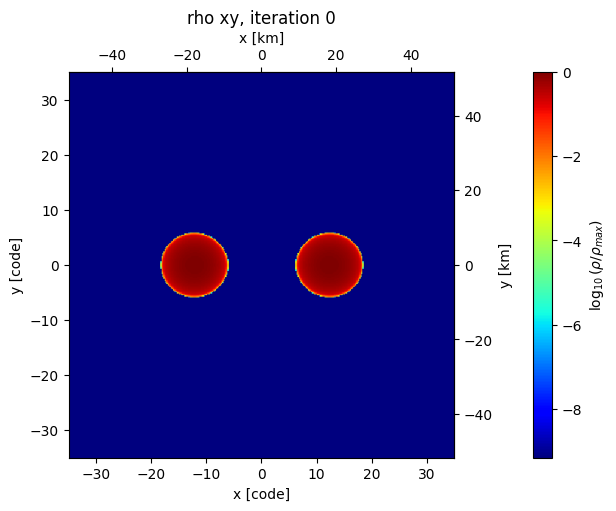

In [15]:
plot_data = np.log10(rho_xy.data.T/rho_xy.max())
km_per_code_length = UC.length / 1e3

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
image = ax.imshow(plot_data, origin="lower", extent=(-35, 35, -35, 35), cmap="jet")

fig.colorbar(image, ax=ax, label=r"$\log_{10}(\rho/\rho_{max})$")

ax.set_xlabel("x [code]")
ax.set_ylabel("y [code]")
ax.set_title(f"rho xy, iteration {it}")

km_x_axis = ax.secondary_xaxis(
    "top",
    functions=(
        lambda xcode: xcode * km_per_code_length,
        lambda x_km: x_km / km_per_code_length,
    ),
)
km_y_axis = ax.secondary_yaxis(
    "right",
    functions=(
        lambda ycode: ycode * km_per_code_length,
        lambda y_km: y_km / km_per_code_length,
    ),
)
km_x_axis.set_xlabel("x [km]")
km_y_axis.set_ylabel("y [km]")
save_plot("03_rho_xy.png")


### 4. Multipoles and gravitational waves

Multipole output is time series data decomposed into spherical-harmonic modes. For gravitational waves we usually start with Psi4, then use fixed-frequency integration to estimate strain.


In [16]:
print(simdir1.multipoles)  # This is a MultipolesDir
print("-------")
psi4_m = simdir1.multipoles["Psi4"] #or .get("Psi4") or .fields.psi4 . This is a MultipoleAllDets

radius0 = psi4_m.radii[0]
psi4_m_r0_22 = psi4_m[radius0][(2,2)] #MulipoleOneDet -> Timeseries
print(psi4_m_r0_22)

Variables available: dict_keys(['psi4'])
For variable psi4:

Avilable radii: [388.8, 453.6, 518.4, 583.2]

At radius 388.8, (l, m) available: [(0, 0), (1, -1), (1, 0), (1, 1), (2, -1), (2, -2), (2, 0), (2, 1), (2, 2), (3, -1), (3, -2), (3, -3), (3, 0), (3, 1), (3, 2), (3, 3), (4, -1), (4, -2), (4, -3), (4, -4), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]
At radius 453.6, (l, m) available: [(0, 0), (1, -1), (1, 0), (1, 1), (2, -1), (2, -2), (2, 0), (2, 1), (2, 2), (3, -1), (3, -2), (3, -3), (3, 0), (3, 1), (3, 2), (3, 3), (4, -1), (4, -2), (4, -3), (4, -4), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]
At radius 518.4, (l, m) available: [(0, 0), (1, -1), (1, 0), (1, 1), (2, -1), (2, -2), (2, 0), (2, 1), (2, 2), (3, -1), (3, -2), (3, -3), (3, 0), (3, 1), (3, 2), (3, 3), (4, -1), (4, -2), (4, -3), (4, -4), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]
At radius 583.2, (l, m) available: [(0, 0), (1, -1), (1, 0), (1, 1), (2, -1), (2, -2), (2, 0), (2, 1), (2, 2), (3, -1), (3, -2), (3, -3), (3, 0), (3, 1), (

kuibit_tutorial_2026_workspace/04_psi4_22.png


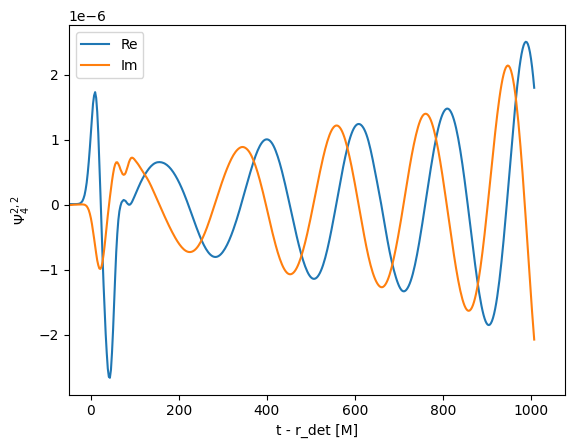

In [17]:
plt.figure()
plt.plot(psi4_m_r0_22.t-radius0, psi4_m_r0_22.values.real, label="Re")
plt.plot(psi4_m_r0_22.t-radius0, psi4_m_r0_22.values.imag, label="Im")

plt.xlim(-50)
plt.xlabel("t - r_det [M]")
plt.ylabel(r"$\Psi_4^{2,2}$")
plt.legend()
save_plot("04_psi4_22.png")


264.0128479621176
Avilable radii: [388.8, 453.6, 518.4, 583.2]

At radius 388.8, (l, m) available: [(2, -2), (2, -1), (2, 0), (2, 1), (2, 2), (3, -3), (3, -2), (3, -1), (3, 0), (3, 1), (3, 2), (3, 3), (4, -4), (4, -3), (4, -2), (4, -1), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]
At radius 453.6, (l, m) available: [(2, -2), (2, -1), (2, 0), (2, 1), (2, 2), (3, -3), (3, -2), (3, -1), (3, 0), (3, 1), (3, 2), (3, 3), (4, -4), (4, -3), (4, -2), (4, -1), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]
At radius 518.4, (l, m) available: [(2, -2), (2, -1), (2, 0), (2, 1), (2, 2), (3, -3), (3, -2), (3, -1), (3, 0), (3, 1), (3, 2), (3, 3), (4, -4), (4, -3), (4, -2), (4, -1), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]
At radius 583.2, (l, m) available: [(2, -2), (2, -1), (2, 0), (2, 1), (2, 2), (3, -3), (3, -2), (3, -1), (3, 0), (3, 1), (3, 2), (3, 3), (4, -4), (4, -3), (4, -2), (4, -1), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]

kuibit_tutorial_2026_workspace/05_strain_22.png


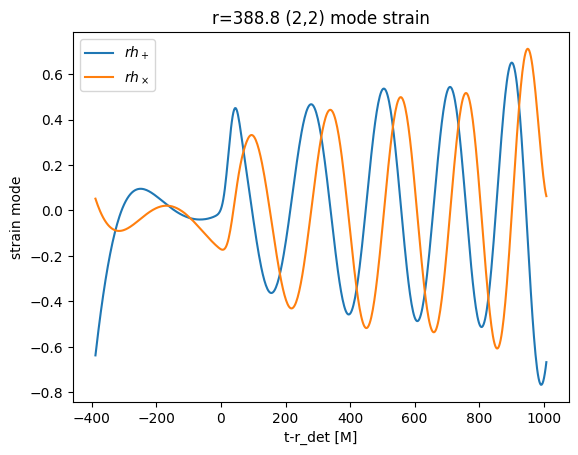

In [18]:
# Kuibit can integrate Psi4 twice to get strain.
# pcut is the fixed-frequency-integration cutoff period; choose it with physics in mind.
omega_ID = 0.0118993930706; omega_cut = 2*omega_ID; 
pcutf = 2*np.pi/omega_cut;
print(pcutf)

print(simdir1.gws); # This is a GravitationalWavesDir
radius0 = simdir1.gws.radii[0]
gw_r0 = simdir1.gws[radius0] # This is a GravitationalWavesOneDet
h_r0_22 = gw_r0.get_strain_lm(2, 2, pcut=pcutf)  # returns r h_+ - i r h_x TimeSeries

plt.figure()
plt.plot(h_r0_22.t-radius0, h_r0_22.values.real, label=r"$r h_+$")
plt.plot(h_r0_22.t-radius0, -h_r0_22.values.imag, label=r"$r h_\times$")

plt.title(f"r={radius0} (2,2) mode strain")
#plt.xlim(-50)
plt.xlabel("t-r_det [M]")
plt.ylabel("strain mode")
plt.legend()
save_plot("05_strain_22.png")


kuibit_tutorial_2026_workspace/06_observed_strain.png


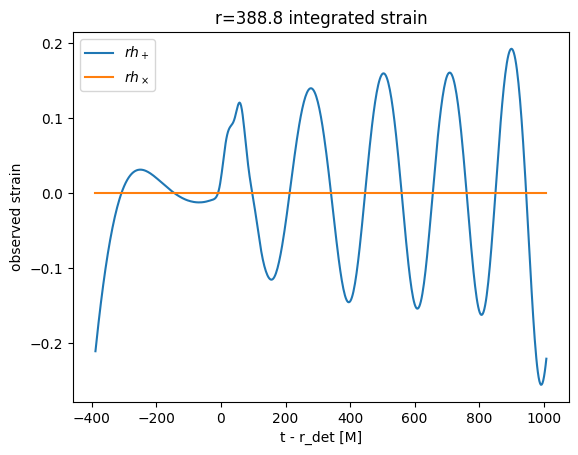

In [19]:
# Same idea, but an observer direction sums all available modes.
# theta=0 is along +z; theta=pi/2 is edge-on.
h_obs = gw_r0.get_strain(theta=np.pi/2, phi=0.0, pcut=pcutf, l_max=4)

plt.figure()
plt.plot(h_obs.t-radius0, h_obs.values.real, label=r"$r h_+$")
plt.plot(h_obs.t-radius0, -h_obs.values.imag, label=r"$r h_\times$")

plt.title(f"r={radius0} integrated strain")
#plt.xlim(-50)
plt.xlabel("t - r_det [M]")
plt.ylabel("observed strain")
plt.legend()
save_plot("06_observed_strain.png")


### 5. A tiny BNS density movie

A movie is just the same 2D plot repeated over many iterations. The cell below writes a small `mopi` movie file and prints the command to run in a terminal. Use `preview_movie = True` first if you want to test the first and last frames before making the full movie.


In [20]:
import textwrap

movie_dir = Path(outdir) / "movies"
movie_dir.mkdir(parents=True, exist_ok=True)

# Movie settings: change these first.
movie_every = 1             # render every Nth available 2D output
movie_xmax = 25.0            # plot x,y in [-movie_xmax, movie_xmax]
movie_resolution = 384       # plotting grid, not simulation resolution
movie_floor = 1.0e-7         # log floor for rho/rho_max(0)
movie_vmin = -7.0
movie_vmax = 0.5
movie_fps = 10
movie_name = "bns_rho_xy"

rho_xy = simdir1.gf.xy["rho"]
movie_iterations = list(rho_xy.available_iterations)
print(f"available frames: {len(movie_iterations)} from it={movie_iterations[0]} to it={movie_iterations[-1]}")

mopi_movie_file = (movie_dir / "bns_rho_xy_mopi.py").resolve()
mopi_outdir = (movie_dir / movie_name).resolve()

mopi_movie_file.write_text(textwrap.dedent(f'''
    from pathlib import Path
    import shutil

    import matplotlib.pyplot as plt
    import numpy as np
    from kuibit.simdir import SimDir

    # Edit these values to customize the movie.
    SIM_DIR = Path({str(bns_simout1.resolve())!r})
    XMAX = {movie_xmax!r}
    RESOLUTION = {movie_resolution!r}
    FLOOR = {movie_floor!r}
    VMIN = {movie_vmin!r}
    VMAX = {movie_vmax!r}
    CLEAN_OUTPUT = True

    class MOPIMovie:
        def __init__(self, args):
            if CLEAN_OUTPUT and not args.only_render_movie:
                shutil.rmtree(args.outdir, ignore_errors=True)

            self.sim = SimDir(SIM_DIR)
            self.rho = self.sim.gf.xy["rho"]
            self.iterations = list(self.rho.available_iterations)
            self.shape = (RESOLUTION, RESOLUTION)
            self.x0 = (-XMAX, -XMAX)
            self.x1 = ( XMAX,  XMAX)
            self.rho0_max = self._grid(0).max()

        def _grid(self, iteration):
            return self.rho[iteration].to_UniformGridData(
                self.shape, x0=self.x0, x1=self.x1, resample=False
            )

        def get_frames(self):
            return self.iterations

        def make_frame(self, path, iteration):
            grid = self._grid(iteration)
            pdata = np.log10(grid.data.T/grid.max())
            time = self.rho.time_at_iteration(iteration)
            

            fig, ax = plt.subplots(figsize=(6, 5), dpi=140)
            image = ax.imshow(
                pdata,
                origin="lower",
                extent=(-XMAX, XMAX, -XMAX, XMAX),
                cmap="jet",
                vmin=VMIN,
                vmax=VMAX,
                interpolation="nearest",
            )
            fig.colorbar(image, ax=ax, label=r"$\\log_{{10}}(\\rho/\\rho_{{max}}(0))$")
            ax.set_xlabel("x [code]")
            ax.set_ylabel("y [code]")
            ax.set_aspect("equal", adjustable="box")
            ax.set_title(rf"BNS $\\rho$ xy, $t={{time:.1f}}\\,M$")
            fig.tight_layout()
            fig.savefig(path)
            plt.close(fig)
            self.rho.clear_cache()
'''))

preview_cmd = (
    f"mopi -m {mopi_movie_file} "
    f"--outdir {movie_dir / (movie_name + '_preview_first')} "
    f"--movie-name {movie_name}_preview_first "
    f"--snapshot {movie_iterations[0]} --overwrite"
)

movie_cmd = (
    f"mopi -m {mopi_movie_file} "
    f"--outdir {mopi_outdir} "
    f"--movie-name {movie_name} "
    f"--frames-every {movie_every} "
    f"--fps {movie_fps} --extension mp4 --overwrite"
)

print("Reusable movie script:")
print(mopi_movie_file)
print("\nPreview command:")
print(preview_cmd)
print("\nFull movie command:")
print(movie_cmd)


available frames: 146 from it=0 to it=74240
Reusable movie script:
/data/mrizzo7/ETK_SumSch/kuibit-tutorial-etksums/notebooks/kuibit_tutorial_2026_workspace/movies/bns_rho_xy_mopi.py

Preview command:
mopi -m /data/mrizzo7/ETK_SumSch/kuibit-tutorial-etksums/notebooks/kuibit_tutorial_2026_workspace/movies/bns_rho_xy_mopi.py --outdir kuibit_tutorial_2026_workspace/movies/bns_rho_xy_preview_first --movie-name bns_rho_xy_preview_first --snapshot 0 --overwrite

Full movie command:
mopi -m /data/mrizzo7/ETK_SumSch/kuibit-tutorial-etksums/notebooks/kuibit_tutorial_2026_workspace/movies/bns_rho_xy_mopi.py --outdir /data/mrizzo7/ETK_SumSch/kuibit-tutorial-etksums/notebooks/kuibit_tutorial_2026_workspace/movies/bns_rho_xy --movie-name bns_rho_xy --frames-every 1 --fps 10 --extension mp4 --overwrite


### Questions or Feature ideas?